### Imports

In [ ]:
!pip install transformers

In [ ]:
import torch
from tqdm.notebook import tqdm

from torch.utils.data import TensorDataset

from google.colab import drive
import pandas as pd

import nltk
import re
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.corpus import stopwords
from  nltk.stem import SnowballStemmer

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight

### Data Load

In [ ]:
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Memoria_Group_Classification/Datos/'
df = pd.read_csv(path + 'dataset_final.csv')
print(df.shape)

In [ ]:
df = df.drop_duplicates(subset=['text'])

In [ ]:
labels_ = [
  'policy_introductory',
  'cookies_and_similar_technologies',
  'third_party_share_and_collection',
  'user_right_and_control',
  'data_security',
  'data_retention',
  'international_data_transfer',
  'specific_audiences',
  'policy_change',
  'policy_contact_information']

### Downsampling the majority class

In [ ]:
class_counts = df['label'].value_counts()
majority_class = class_counts.idxmax()

majority_class_df = df[df['label'] == majority_class]
downsampled_majority_class_df = majority_class_df.sample(n=3000, random_state=42)

balanced_df = pd.concat([df[df['label'].isin(labels_)], downsampled_majority_class_df])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

df = balanced_df
df.head()

### Clean Data

In [ ]:
stop_words = stopwords.words("english")

stemmer = SnowballStemmer("english")

def clean_text(text):
  TEXT_CLEANING_RE = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
  TEXT_CLEANING_RE_EXTRA = "[^\w\s]"
  text = re.sub(TEXT_CLEANING_RE, ' ', str(text).lower()).strip()
  text = re.sub(TEXT_CLEANING_RE_EXTRA, ' ', str(text).lower()).strip()
  return text

def preprocess(text,cleaning=True,stopwords=True,stemming=True):
    if cleaning:
      text = clean_text(text)
    tokens = []
    for token in text.split():
        if (not stopwords) or (stopwords and (token not in stop_words)):
            if stemming:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# df['cleaned_text'] = df['text'].apply(lambda x: preprocess(x))

### Encoded Label

In [ ]:
possible_labels = df.label.unique()

label_dict = {}
for index, possible_label in enumerate(possible_labels):
    label_dict[possible_label] = index
label_dict

{'third_party_share_and_collection': 0,
 'user_right_and_control': 1,
 'specific_audiences': 2,
 'data_security': 3,
 'first_party_collection_and_use': 4,
 'policy_change': 5,
 'policy_contact_information': 6,
 'international_data_transfer': 7,
 'cookies_and_similar_technologies': 8,
 'data_retention': 9,
 'policy_introductory': 10}

In [ ]:
df['clase'] = df.label.replace(label_dict)

### Split data 

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(df.index.values,
                                                  df.clase.values,
                                                  test_size=0.15,
                                                  random_state=42,
                                                  stratify=df.clase.values)

In [ ]:
df['data_type'] = ['not_set']*df.shape[0]

df.loc[X_train, 'data_type'] = 'train'
df.loc[X_val, 'data_type'] = 'val'

In [ ]:
df.groupby(['label', 'clase', 'data_type']).count()

### Prepare Input for BERT 

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
MAX_LENGTH = 128
encoded_data_train = tokenizer.batch_encode_plus(
    list(df[df.data_type=='train'].text.values),
    add_special_tokens=True,
    return_attention_mask=True,
    pad_to_max_length=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

encoded_data_val = tokenizer.batch_encode_plus(
    list(df[df.data_type=='val'].text.values),
    add_special_tokens=True,
    return_attention_mask=True,
    pad_to_max_length=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)


input_ids_train = encoded_data_train['input_ids']
attention_masks_train = encoded_data_train['attention_mask']
labels_train = torch.tensor(df[df.data_type=='train'].clase.values)

input_ids_val = encoded_data_val['input_ids']
attention_masks_val = encoded_data_val['attention_mask']
labels_val = torch.tensor(df[df.data_type=='val'].clase.values)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2614: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [ ]:
dataset_train = TensorDataset(input_ids_train, attention_masks_train, labels_train)
dataset_val = TensorDataset(input_ids_val, attention_masks_val, labels_val)

In [ ]:
len(dataset_train), len(dataset_val)

(11906, 2102)

### Model Arquitecture

In [ ]:
from transformers import BertModel
import torch.nn as nn

class CustomBERTModel(nn.Module):
    def __init__(self):
          super(CustomBERTModel, self).__init__()
          self.bert = BertModel.from_pretrained("bert-base-uncased", return_dict=False)
          self.pooling = nn.AdaptiveAvgPool2d((1, 768)) # , stride=2
          self.dropout = nn.Dropout(p=0.7)
          # self.linear1 = nn.Linear(768, 256)
          self.linear2 = nn.Linear(768, 11) ## 3 is the number of classes in this example

    def forward(self, ids, mask):
          sequence_output, pooled_output = self.bert(
               ids,
               attention_mask=mask)

          # pooling1d = self.pooling(sequence_output) # sequence_output[:,0,:].view(-1,768)
          pooled_output = self.pooling(sequence_output).squeeze(1)
          dropout = self.dropout(pooled_output)

          # linear1_output = self.linear1(dropout)

          linear2_output = self.linear2(dropout)

          return linear2_output

In [ ]:
from transformers import BertForSequenceClassification

model = CustomBERTModel() # You can pass the parameters if required to have more flexible model

In [ ]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

batch_size = 16

dataloader_train = DataLoader(dataset_train,
                              sampler=RandomSampler(dataset_train),
                              batch_size=batch_size)

dataloader_validation = DataLoader(dataset_val,
                                   sampler=SequentialSampler(dataset_val),
                                   batch_size=batch_size)

In [ ]:
from transformers import AdamW, get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(),
                  lr=1e-5,
                  eps=1e-8)

In [ ]:
epochs = 5

scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=0,
                                            num_training_steps=len(dataloader_train)*epochs)

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

def f1_score_func(preds, labels):
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return f1_score(labels_flat, preds_flat, average='macro') # weighted

def accuracy_per_class(preds, labels):
    label_dict_inverse = {v: k for k, v in label_dict.items()}

    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()

    for label in np.unique(labels_flat):
        y_preds = preds_flat[labels_flat==label]
        y_true = labels_flat[labels_flat==label]
        print(f'Class: {label_dict_inverse[label]}')
        print(f'Accuracy: {len(y_preds[y_preds==label])}/{len(y_true)}\n')

In [ ]:
import random

seed_val = 17
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(device)

cuda


### Compute class weights

In [ ]:
class_series = labels_train.numpy()
class_labels = np.unique(class_series)
pesos = compute_class_weight(class_weight='balanced', classes=class_labels, y=class_series)
class_weights = dict(zip(class_labels, pesos))
class_weights

{0: 0.4454171343060232,
 1: 0.5371531694112339,
 2: 1.7071981646114138,
 3: 1.5551201671891326,
 4: 0.42445632798573973,
 5: 2.437755937755938,
 6: 2.7471158283341026,
 7: 3.1648059542796383,
 8: 1.0812823540096268,
 9: 3.320133853876185,
 10: 1.0077873709158625}

In [ ]:
weights = torch.tensor(pesos, dtype=torch.float32).to(device)
weights

tensor([0.4454, 0.5372, 1.7072, 1.5551, 0.4245, 2.4378, 2.7471, 3.1648, 1.0813,
        3.3201, 1.0078], device='cuda:0')

In [ ]:
def evaluate(dataloader_val):

    model.eval()

    loss_val_total = 0
    predictions, true_vals = [], []

    for batch in dataloader_val:

        batch = tuple(b.to(device) for b in batch)

        inputs = {'ids':      batch[0],
                  'mask':     batch[1],
                 }

        labels = batch[2]

        with torch.no_grad():
            outputs = model(**inputs)

        criterion = torch.nn.CrossEntropyLoss(weight=weights)
        loss = criterion(outputs, labels)

        logits = outputs
        loss_val_total += loss.item()

        logits = logits.detach().cpu().numpy()
        label_ids = labels.cpu().numpy()
        predictions.append(logits)
        true_vals.append(label_ids)

    loss_val_avg = loss_val_total/len(dataloader_val)

    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    return loss_val_avg, predictions, true_vals

In [ ]:
path_model = '/content/drive/MyDrive/Memoria_Group_Classification/Modelos/'

train_loss_history = []
val_loss_history = []

for epoch in tqdm(range(1, epochs+1)):

    model.train()

    loss_train_total = 0

    progress_bar = tqdm(dataloader_train, desc='Epoch {:1d}'.format(epoch), leave=False, disable=False)
    for batch in progress_bar:

        model.zero_grad()

        batch = tuple(b.to(device) for b in batch)

        inputs = {'ids':      batch[0],
                  'mask':     batch[1],
                 }

        labels = batch[2]

        outputs = model(**inputs)
        outputs = torch.nn.functional.log_softmax(outputs, dim=1)

        criterion = torch.nn.CrossEntropyLoss(weight=weights)
        loss = criterion(outputs, labels)

        loss_train_total += loss.item()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item()/len(batch))})


    torch.save(model.state_dict(), path_model + f'finetuned_BERT_epoch_{epoch}.model')

    tqdm.write(f'\nEpoch {epoch}')

    loss_train_avg = loss_train_total/len(dataloader_train)
    tqdm.write(f'Training loss: {loss_train_avg}')

    val_loss, predictions, true_vals = evaluate(dataloader_validation)
    val_f1 = f1_score_func(predictions, true_vals)
    tqdm.write(f'Validation loss: {val_loss}')
    tqdm.write(f'F1 Score (Weighted): {val_f1}')

    train_loss_history.append(loss_train_avg)
    val_loss_history.append(val_loss)

In [ ]:
#requiere predicciones categóricas
def get_detailed_report(y_true_test, y_pred_test, class_names):
    acc_test = np.mean(y_true_test == y_pred_test)
    print("\nACCURACY: " , acc_test )
    print("\nConfusion Matrix\n")
    fig, ax = plt.subplots(figsize=(6, 6))
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    plt.rcParams.update({'font.size': 9})
    plt.rc('xtick', labelsize=9)
    plt.rc('ytick', labelsize=9)
    plt.xlabel('Predicted Label', fontsize=9)
    plt.ylabel('True Label', fontsize=9)
    disp = disp.plot(ax=ax,cmap=plt.cm.Blues)
    plt.show()
    print("\nClassification Report\n")
    print(classification_report(y_true_test, y_pred_test, target_names=class_names))

In [ ]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_metrics(train_history, val_history, metrics = ['accuracy', 'F1']):

    plt.plot(train_history, color=colors[0], label='train')
    plt.plot(val_history,
             color=colors[0], linestyle="--", label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([0, plt.ylim()[1]])
    plt.legend();

In [ ]:
val_labels = []
for data, _, labels in dataloader_validation:
    # 'labels' contains the labels for the current batch
    # Append the labels to the 'all_labels' list
    for x in labels:
        val_labels.append(x.item())


ACCURACY:  0.7240723120837298

Confusion Matrix



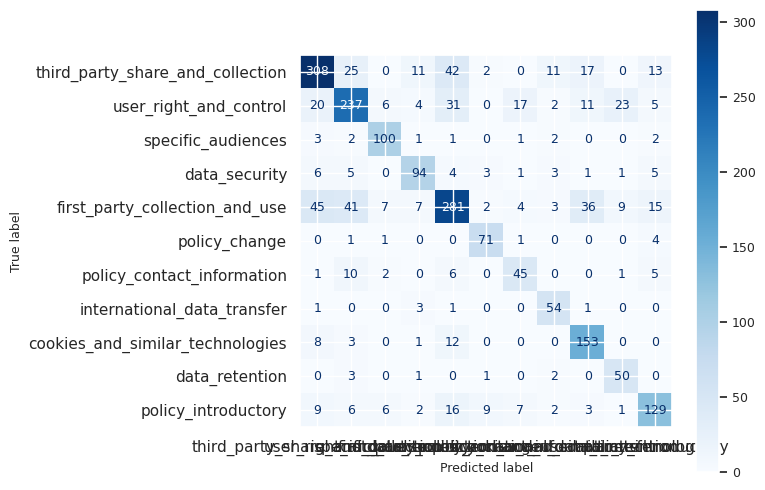


Classification Report

                                  precision    recall  f1-score   support

third_party_share_and_collection       0.77      0.72      0.74       429
          user_right_and_control       0.71      0.67      0.69       356
              specific_audiences       0.82      0.89      0.85       112
                   data_security       0.76      0.76      0.76       123
  first_party_collection_and_use       0.71      0.62      0.67       450
                   policy_change       0.81      0.91      0.86        78
      policy_contact_information       0.59      0.64      0.62        70
     international_data_transfer       0.68      0.90      0.78        60
cookies_and_similar_technologies       0.69      0.86      0.77       177
                  data_retention       0.59      0.88      0.70        57
             policy_introductory       0.72      0.68      0.70       190

                        accuracy                           0.72      2102
            

In [ ]:
_, predictions, true_vals = evaluate(dataloader_validation)
y_pred = predictions.argmax(axis=1)
get_detailed_report(val_labels, y_pred, label_dict.keys())

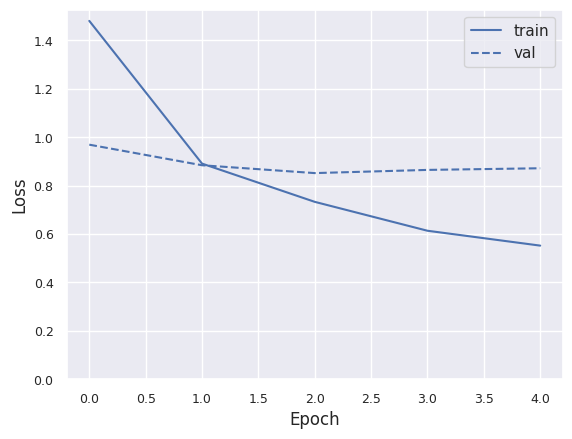

In [ ]:
plot_metrics(train_loss_history, val_loss_history)

In [ ]:
from transformers import AutoConfig

configuration = AutoConfig.from_pretrained('bert-base-uncased')
configuration.num_labels = 11
configuration.output_attentions = False
configuration.output_hidden_states = False
configuration.classifier_dropout = 0.7
model = BertForSequenceClassification.from_pretrained("bert-base-uncased",
                                                      config = configuration)

model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
model = CustomBERTModel()
model.to(device)

In [ ]:
epoch = 3
model.load_state_dict(torch.load( path_model + f'finetuned_BERT_epoch_{epoch}.model', map_location=torch.device('cuda')))

In [ ]:
_, predictions, true_vals = evaluate(dataloader_validation)
y_pred = predictions.argmax(axis=1)
get_detailed_report(val_labels, y_pred, label_dict.keys())

In [ ]:
accuracy_per_class(predictions, true_vals)